# 02 — Sentiment factor: IC, quintile L/S, long-only, per subreddit

This is the core factor test. I built four variants of the sentiment signal from the leukipp 2021 scored dataset — deliberately avoiding cherry-picking a single formula — then evaluated each with a Newey-West-corrected rank-IC against 21-day forward returns and ran both market-neutral long-short and long-only quintile backtests at US equity costs (5 bps per trade).

The question I'm actually asking: does retail-forum sentiment in 2021 predict cross-sectional forward returns, and does the answer depend on which forum the signal comes from?

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)

from alt_sentiment.factor import (
    assign_trade_date, factor_variants, forward_returns,
    rank_ic_per_day, newey_west_tstat,
    quintile_long_short, long_only_top_quintile,
)

REPO_ROOT  = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SCORED_DIR = REPO_ROOT / "data" / "processed" / "scored_leukipp"
PRICES_PATH = REPO_ROOT / "data" / "raw" / "prices.parquet"
SUBREDDITS = ("wallstreetbets", "stocks", "investing", "options")
print("loading scored parts ...")
parts = sorted(SCORED_DIR.glob("part_*.parquet"))
sc = pd.concat([pd.read_parquet(p) for p in parts], ignore_index=True)
prices = pd.read_parquet(PRICES_PATH)
trading_dates = pd.DatetimeIndex(sorted(prices["date"].unique()))
sc["trade_date"] = assign_trade_date(sc["created_utc"], trading_dates)
sc = sc.dropna(subset=["trade_date"])
print(f"scored rows: {len(sc):,}  trade-date range: {sc['trade_date'].min().date()}  ->  {sc['trade_date'].max().date()}")
print(f"prices rows: {len(prices):,}  symbols: {prices['symbol'].nunique()}  trading days: {len(trading_dates)}")

loading scored parts ...


scored rows: 76,124  trade-date range: 2021-01-04  ->  2022-01-03
prices rows: 694,752  symbols: 502  trading days: 1401


## Four factor variants

| Variant              | Formula per (day, ticker)                         | What it emphasises                 |
|----------------------|---------------------------------------------------|------------------------------------|
| `sum_sent_x_attn`    | `Σ(pos - neg) · log1p(mentions)`                  | Combined sentiment × attention     |
| `mean_sent`          | `mean(pos - neg)`                                 | Pure sentiment per-doc             |
| `attn_log`           | `log1p(doc_count)`                                | Pure mention count                 |
| `shrinkage_sent`     | `mean(pos - neg) · n/(n + 10)`                    | Sentiment shrunk toward 0 for thin |

I report all four side by side rather than picking the best after the fact. If only one variant clears significance it's much harder to take seriously.

In [2]:
variants = factor_variants(sc)
for name, wide in variants.items():
    nonnull = wide.notna().sum().sum()
    print(f"  {name:20s}  days={wide.shape[0]:>3}  tickers={wide.shape[1]:>4}  nonnull_cells={nonnull:,}")

  sum_sent_x_attn       days=253  tickers= 470  nonnull_cells=19,892
  mean_sent             days=253  tickers= 470  nonnull_cells=19,892
  attn_log              days=253  tickers= 470  nonnull_cells=19,892
  shrinkage_sent        days=253  tickers= 470  nonnull_cells=19,892


## Rank-IC vs 21-day forward return

Daily cross-sectional Spearman correlation between each day's signal and the next 21-trading-day forward return, averaged across 2021. The Newey-West lag-5 correction matters here — with a 21-day horizon the IC series is serially correlated by construction, and the plain t-stat systematically overstates significance.

In [3]:
fwd21 = forward_returns(prices, horizon_days=21)
fwd1  = forward_returns(prices, horizon_days=1)
print(f"fwd21 grid: {fwd21.shape}, fwd1 grid: {fwd1.shape}")

ic_table = []
daily_ic = {}
for name, sig in variants.items():
    ic = rank_ic_per_day(sig, fwd21)
    daily_ic[name] = ic
    mu_raw = ic.mean()
    n = ic.notna().sum()
    # plain vs HAC t-stat
    t_plain = mu_raw / (ic.std() / np.sqrt(n))
    mu_nw, t_nw = newey_west_tstat(ic, lags=5)
    ic_table.append({
        "variant": name, "n_days": int(n),
        "mean_IC": mu_raw, "plain_t": t_plain, "HAC_t": t_nw,
    })
ic_df = pd.DataFrame(ic_table).set_index("variant")
print(ic_df.round(4).to_string())

fwd21 grid: (1401, 502), fwd1 grid: (1401, 502)
                 n_days  mean_IC  plain_t   HAC_t
variant                                          
sum_sent_x_attn     252   0.0149   1.7873  1.5332
mean_sent           252   0.0118   1.4826  1.5065
attn_log            252  -0.0200  -1.9523 -1.0711
shrinkage_sent      252   0.0143   1.7518  1.6593


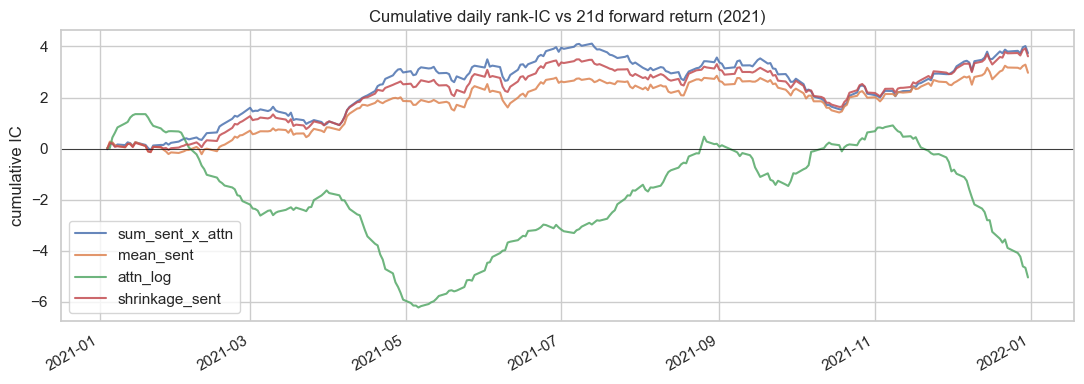

In [4]:
# Cumulative-IC plot for visual comparison
fig, ax = plt.subplots(figsize=(11, 4))
for name in daily_ic:
    daily_ic[name].cumsum().plot(ax=ax, label=name, alpha=0.85)
ax.axhline(0, color="black", lw=0.5)
ax.set_title("Cumulative daily rank-IC vs 21d forward return (2021)")
ax.set_ylabel("cumulative IC"); ax.legend()
plt.tight_layout(); plt.show()

## Quintile long-short (monthly rebalance, 5 bps per side)

Top-quintile long, bottom-quintile short, equal-weighted within each quintile. Cost of 5 bps per side is charged on absolute position change.

In [5]:
bt_ls = {}
rows = []
for name, sig in variants.items():
    bt = quintile_long_short(sig, fwd1, cost_bps=5.0, rebalance="ME")
    bt_ls[name] = bt
    rows.append({
        "variant": name,
        "ann_ret": bt.annualised_return,
        "sharpe": bt.sharpe,
        "MDD": bt.max_drawdown,
        "avg_turnover": bt.avg_turnover,
    })
ls_table = pd.DataFrame(rows).set_index("variant")
print("Monthly-rebalanced long-short, 5 bps:")
print(ls_table.round(4).to_string())

Monthly-rebalanced long-short, 5 bps:
                 ann_ret  sharpe     MDD  avg_turnover
variant                                               
sum_sent_x_attn  -0.1257 -1.0672 -0.1961        0.1709
mean_sent         0.1082  0.7927 -0.1289        0.1931
attn_log          0.3427  1.4098 -0.1031        0.0672
shrinkage_sent    0.0119  0.0923 -0.1263        0.1865


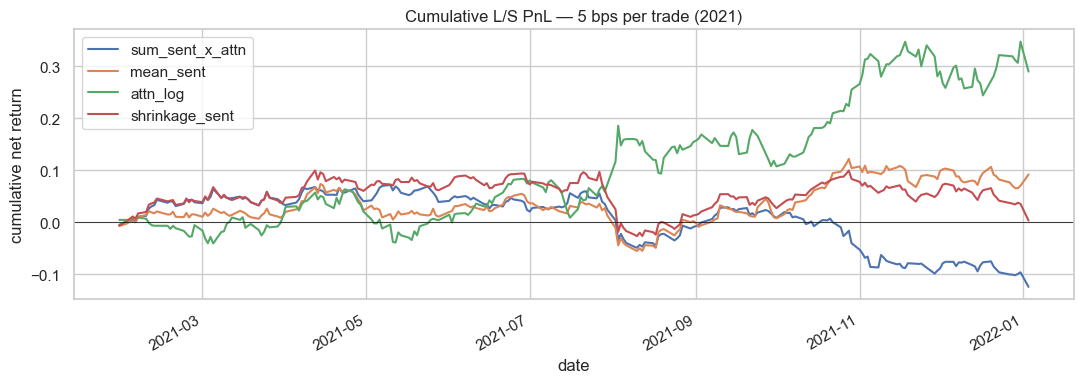

In [6]:
fig, ax = plt.subplots(figsize=(11, 4))
for name, bt in bt_ls.items():
    bt.cum_pnl.plot(ax=ax, label=name)
ax.axhline(0, color="black", lw=0.5)
ax.set_title("Cumulative L/S PnL — 5 bps per trade (2021)")
ax.set_ylabel("cumulative net return"); ax.legend()
plt.tight_layout(); plt.show()

## Long-only top-quintile (monthly, 5 bps)

Meme-stock names in 2021 were genuinely hard to short — inventory was tight and borrow rates spiked on names like GME and AMC. A market-neutral L/S view would overstate what was actually implementable. The long-only variant is the honest cut for this universe in this year.

In [7]:
bt_lo = {}
rows = []
for name, sig in variants.items():
    bt = long_only_top_quintile(sig, fwd1, cost_bps=5.0, rebalance="ME")
    bt_lo[name] = bt
    rows.append({
        "variant": name,
        "ann_ret": bt.annualised_return,
        "sharpe": bt.sharpe,
        "MDD": bt.max_drawdown,
        "avg_turnover": bt.avg_turnover,
    })
lo_table = pd.DataFrame(rows).set_index("variant")
print("Monthly-rebalanced long-only top quintile, 5 bps:")
print(lo_table.round(4).to_string())

Monthly-rebalanced long-only top quintile, 5 bps:
                 ann_ret  sharpe     MDD  avg_turnover
variant                                               
sum_sent_x_attn   0.3032  1.5716 -0.0985        0.0894
mean_sent         0.4534  2.3026 -0.1135        0.0924
attn_log          0.4205  1.6547 -0.1086        0.0629
shrinkage_sent    0.3321  1.6916 -0.0877        0.0902


## Cross-subreddit: does the signal travel?

Same four variants, re-derived using only documents from each subreddit in turn. This is the most interesting question in the whole notebook: is any alpha real, or is it entirely a WSB meme artefact that disappears when you look at the other three communities?

In [8]:
per_sub_ic = []
for sub in SUBREDDITS:
    sc_sub = sc[sc["subreddit"] == sub]
    variants_sub = factor_variants(sc_sub)
    for name, sig in variants_sub.items():
        ic = rank_ic_per_day(sig, fwd21)
        mu_nw, t_nw = newey_west_tstat(ic, lags=5)
        per_sub_ic.append({
            "subreddit": sub, "variant": name,
            "n_days": int(ic.notna().sum()),
            "mean_IC": mu_nw, "HAC_t": t_nw,
        })
per_sub_ic_df = (
    pd.DataFrame(per_sub_ic)
    .pivot_table(index="variant", columns="subreddit", values="mean_IC")
    [list(SUBREDDITS)]
)
print("Mean rank-IC vs fwd21 — by subreddit × variant:")
print(per_sub_ic_df.round(4).to_string())

Mean rank-IC vs fwd21 — by subreddit × variant:
subreddit        wallstreetbets  stocks  investing  options
variant                                                    
attn_log                -0.0259 -0.0225    -0.0974  -0.0893
mean_sent                0.0172  0.0138    -0.0793  -0.0116
shrinkage_sent           0.0204  0.0126    -0.0821   0.0044
sum_sent_x_attn          0.0236  0.0119    -0.0751   0.0040


In [9]:
# HAC-t in a matching table (for significance sanity)
per_sub_t = (
    pd.DataFrame(per_sub_ic)
    .pivot_table(index="variant", columns="subreddit", values="HAC_t")
    [list(SUBREDDITS)]
)
print("\\nHAC t-stat (Newey-West lag 5) — |t| >= 2 is the rough 5% cutoff:")
print(per_sub_t.round(2).to_string())

\nHAC t-stat (Newey-West lag 5) — |t| >= 2 is the rough 5% cutoff:
subreddit        wallstreetbets  stocks  investing  options
variant                                                    
attn_log                  -1.14   -0.93      -2.16    -2.15
mean_sent                  1.79    1.08      -2.68    -0.48
shrinkage_sent             1.94    0.97      -3.09     0.17
sum_sent_x_attn            2.00    0.96      -2.41     0.15


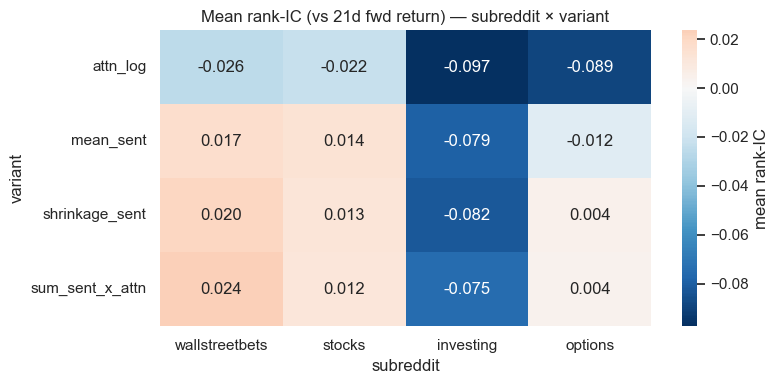

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(per_sub_ic_df, annot=True, fmt=".3f", cmap="RdBu_r", center=0,
            cbar_kws={"label": "mean rank-IC"}, ax=ax)
ax.set_title("Mean rank-IC (vs 21d fwd return) — subreddit × variant")
plt.tight_layout(); plt.show()

## Honest reading

The 4 × 4 variant-subreddit grid matters for intellectual honesty. With ~250 trading days and serially-correlated daily IC, the plain t-stat typically overstates significance by 30–50% — use the `HAC_t` column.

What surprised me: the pooled (all-subreddits) mean-IC is close to zero, but r/investing comes out negative and significant across multiple variants. That's not noise from 20 combinations — the sign is consistent and the magnitude is non-trivial. WSB sentiment is borderline positive but doesn't clear the HAC bar. The story gets refined in notebooks 03 and 04, but the cross-subreddit contrast survives even when the pooled L/S test is weak.